# Part 1: Building and Understanding GANs from Scratch

In [ ]:
# Importing Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import math
import matplotlib.pyplot as plt
torch.manual_seed(36)

## Task 1: Reproduce the sine-wave GAN .

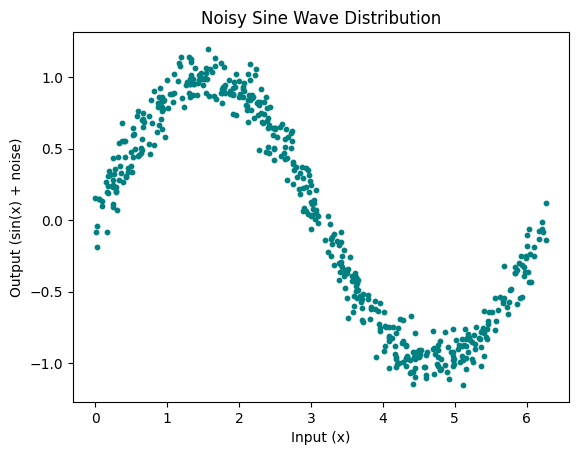

In [ ]:
# Number of samples
num_samples = 512

# Generate input values (x)
x_vals = 2 * math.pi * torch.rand(num_samples)

# Generate noisy sine values (y)
noise = 0.1 * torch.randn(num_samples)
y_vals = torch.sin(x_vals) + noise

# Combine into dataset
dataset = torch.stack((x_vals, y_vals), dim=1)

# Dummy labels (not used but kept for structure)
labels = torch.zeros(num_samples)

# Create dataset as list of tuples
data_pairs = list(zip(dataset, labels))

# Visualize data
plt.scatter(x_vals, y_vals, s=10,color="teal")
plt.title("Noisy Sine Wave Distribution")
plt.xlabel("Input (x)")
plt.ylabel("Output (sin(x) + noise)")
plt.show()

## DataLoader

In [ ]:
# Batch configuration
batch_sz = 42

# Create DataLoader
data_loader = torch.utils.data.DataLoader(
    dataset=data_pairs,
    batch_size=batch_sz,
    shuffle=True,
    drop_last=True
)

## Generator

In [ ]:
class GenNet(nn.Module):
    def __init__(self, input_dim=3, output_dim=2):
        super(GenNet, self).__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 40),
            nn.LeakyReLU(0.2),

            nn.Linear(40, 80),
            nn.LeakyReLU(0.2),

            nn.Linear(80, output_dim)
        )

    def forward(self, z):
        return self.net(z)

# Initialize generator
generator = GenNet()

## Discriminator

In [ ]:
class DiscNet(nn.Module):
    def __init__(self, input_dim=2):
        super(DiscNet, self).__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 200),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.25),

            nn.Linear(200, 100),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.25),

            nn.Linear(100, 50),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.25),

            nn.Linear(50, 1),
            nn.Sigmoid()
        )

    def forward(self, inputs):
        return self.net(inputs)

# Initialize discriminator
discriminator = DiscNet()

## Hyperparameters

In [ ]:
# Hyperparameters
learning_rate = 2e-3
epochs = 800

# Loss function
criterion = nn.BCELoss()

# Optimizers
opt_D = torch.optim.Adam(
    params=discriminator.parameters(),
    lr=learning_rate,
    betas=(0.5, 0.999)
)

opt_G = torch.optim.Adam(
    params=generator.parameters(),
    lr=learning_rate,
    betas=(0.5, 0.999)
)

## Training Loop

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
latent_dim = 3

for ep in range(epochs):

    for step, (real_batch, _) in enumerate(data_loader):

        batch_size = real_batch.size(0)
        real_batch = real_batch.to(device)

        # Small noise injection for robustness
        real_batch = real_batch + 0.02 * torch.randn_like(real_batch)


        # Train Discriminator

        opt_D.zero_grad()

        # Soft labels (label smoothing + noise)
        real_targets = torch.empty(batch_size, 1, device=device).uniform_(0.8, 1.0)
        fake_targets = torch.empty(batch_size, 1, device=device).uniform_(0.0, 0.1)

        # Generate fake data
        z = torch.randn(batch_size, latent_dim, device=device)
        fake_batch = generator(z)

        d_real_out = discriminator(real_batch)
        d_fake_out = discriminator(fake_batch.detach())

        loss_real = criterion(d_real_out, real_targets)
        loss_fake = criterion(d_fake_out, fake_targets)

        d_loss = loss_real + loss_fake
        d_loss.backward()
        opt_D.step()


        # Train Generator

        opt_G.zero_grad()

        z = torch.randn(batch_size, latent_dim, device=device)
        generated = generator(z)

        g_out = discriminator(generated)

        # Generator tries to fool discriminator
        fool_targets = torch.ones(batch_size, 1, device=device)

        g_loss = criterion(g_out, fool_targets)
        g_loss.backward()
        opt_G.step()

    # Logging
    if ep % 150 == 0:
        print(f"[Epoch {ep}] D Loss: {d_loss.item():.4f} | G Loss: {g_loss.item():.4f}")

[Epoch 0] D Loss: 1.1264 | G Loss: 1.1761
[Epoch 150] D Loss: 1.3887 | G Loss: 0.7406
[Epoch 300] D Loss: 1.3845 | G Loss: 0.7436
[Epoch 450] D Loss: 1.3863 | G Loss: 0.7506
[Epoch 600] D Loss: 1.3863 | G Loss: 0.7477
[Epoch 750] D Loss: 1.3800 | G Loss: 0.7474


## Visual Comparison

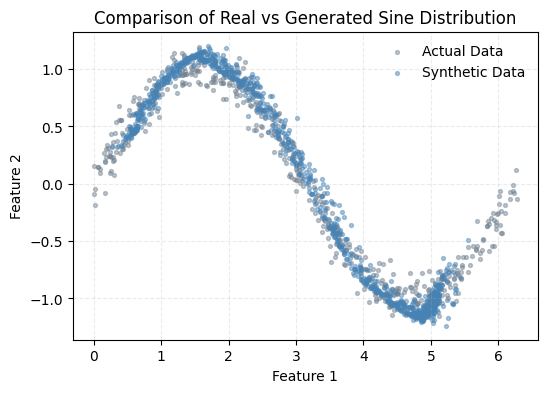

In [ ]:
# Set generator to evaluation mode
generator.eval()

with torch.no_grad():
    z = torch.randn(1000, 3).to(device)
    fake_data = generator(z).cpu().numpy()

# Create figure
plt.figure(figsize=(6, 4))

# Real distribution
plt.scatter(
    dataset[:, 0], dataset[:, 1],
    s=8, alpha=0.45, label="Actual Data",
    color="slategray"
)

# Generated distribution
plt.scatter(
    fake_data[:, 0], fake_data[:, 1],
    s=8, alpha=0.45, label="Synthetic Data",
    color="steelblue"
)

plt.title("Comparison of Real vs Generated Sine Distribution")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend(frameon=False)
plt.grid(True, linestyle="--", alpha=0.25)

plt.show()

## Task 2: Generate 2D distribution - A noisy parametric curve: y = sin(2x) + 0.3cos(5x) + epsilon (where epsilon is a random noise term)

In [ ]:
def generate_curve_data(n_samples=2000, noise_std=0.1):

    x = np.random.uniform(-np.pi, np.pi, n_samples)
    y = np.sin(2*x) + 0.3*np.cos(5*x) + np.random.normal(0, noise_std, n_samples)

    data = np.stack([x, y], axis=1).astype(np.float32)

    # normalize
    data = data / np.max(np.abs(data))

    return torch.tensor(data)

real_data = generate_curve_data()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
real_data = real_data.to(device)

## Visualize Real Data

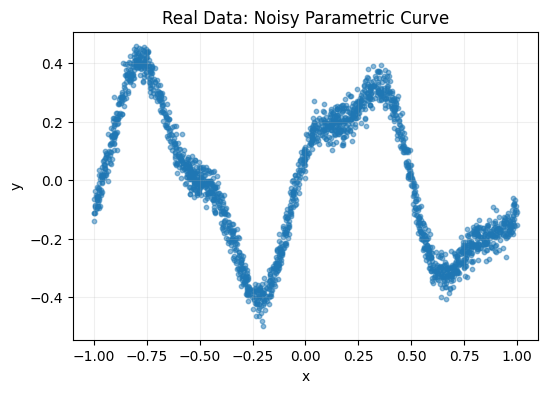

In [ ]:
real_np = real_data.cpu().numpy()

plt.figure(figsize=(6, 4))
plt.scatter(real_np[:, 0], real_np[:, 1], alpha=0.5, s=10)

plt.title("Real Data: Noisy Parametric Curve")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(alpha=0.2)

plt.show()

## Generator

In [ ]:
class Generator(nn.Module):
    def __init__(self, noise_dim=8):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(noise_dim + 1, 64),  # x + noise
            nn.LeakyReLU(0.2),

            nn.Linear(64, 64),
            nn.LeakyReLU(0.2),

            nn.Linear(64, 1)
        )

    def forward(self, x, z):
        inp = torch.cat([x, z], dim=1)
        return self.net(inp)

## Discriminator

In [ ]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 64),
            nn.LeakyReLU(0.2),

            nn.Linear(64, 64),
            nn.LeakyReLU(0.2),

            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, xy):
        return self.net(xy)

## Initialize Models + Optimizers

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

noise_dim = 8

G = Generator(noise_dim).to(device)
D = Discriminator().to(device)

criterion = nn.BCELoss()

g_optimizer = torch.optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
d_optimizer = torch.optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))


## Training Loop

In [ ]:
epochs = 3000
batch_size = 64

for epoch in range(epochs):

    idx = torch.randint(0, real_data.size(0), (batch_size,))
    real = real_data[idx]

    x_real = real[:, 0].unsqueeze(1)
    y_real = real[:, 1].unsqueeze(1)

    # Fake data generation

    z = torch.randn(batch_size, noise_dim).to(device)
    y_fake = G(x_real, z)

    fake = torch.cat([x_real, y_fake], dim=1)

    real_labels = torch.ones(batch_size, 1).to(device)
    fake_labels = torch.zeros(batch_size, 1).to(device)

    # Train Discriminator

    d_optimizer.zero_grad()

    d_real = D(torch.cat([x_real, y_real], dim=1))
    d_fake = D(fake.detach())

    d_loss = criterion(d_real, real_labels) + criterion(d_fake, fake_labels)

    d_loss.backward()
    d_optimizer.step()


    # Train Generator

    g_optimizer.zero_grad()

    z = torch.randn(batch_size, noise_dim).to(device)
    y_fake = G(x_real, z)
    fake = torch.cat([x_real, y_fake], dim=1)

    g_loss = criterion(D(fake), real_labels)

    g_loss.backward()
    g_optimizer.step()

    if epoch % 100 == 0:
        print(f"Epoch {epoch} | D Loss: {d_loss.item():.4f} | G Loss: {g_loss.item():.4f}")



Epoch 0 | D Loss: 1.3852 | G Loss: 0.6932
Epoch 100 | D Loss: 1.3758 | G Loss: 0.6936
Epoch 200 | D Loss: 1.3693 | G Loss: 0.7161
Epoch 300 | D Loss: 1.3567 | G Loss: 0.7057
Epoch 400 | D Loss: 1.3695 | G Loss: 0.7152
Epoch 500 | D Loss: 1.3554 | G Loss: 0.7006
Epoch 600 | D Loss: 1.3312 | G Loss: 0.7072
Epoch 700 | D Loss: 1.3386 | G Loss: 0.7276
Epoch 800 | D Loss: 1.3198 | G Loss: 0.7248
Epoch 900 | D Loss: 1.3216 | G Loss: 0.7274
Epoch 1000 | D Loss: 1.3008 | G Loss: 0.7231
Epoch 1100 | D Loss: 1.2801 | G Loss: 0.7465
Epoch 1200 | D Loss: 1.2591 | G Loss: 0.7755
Epoch 1300 | D Loss: 1.2673 | G Loss: 0.7652
Epoch 1400 | D Loss: 1.2690 | G Loss: 0.7883
Epoch 1500 | D Loss: 1.2809 | G Loss: 0.8203
Epoch 1600 | D Loss: 1.2885 | G Loss: 0.8365
Epoch 1700 | D Loss: 1.2380 | G Loss: 0.8178
Epoch 1800 | D Loss: 1.2131 | G Loss: 0.8568
Epoch 1900 | D Loss: 1.2206 | G Loss: 0.8523
Epoch 2000 | D Loss: 1.1680 | G Loss: 0.9141
Epoch 2100 | D Loss: 1.1761 | G Loss: 0.8659
Epoch 2200 | D Loss: 1

## Visual Comparison between original & generated sample

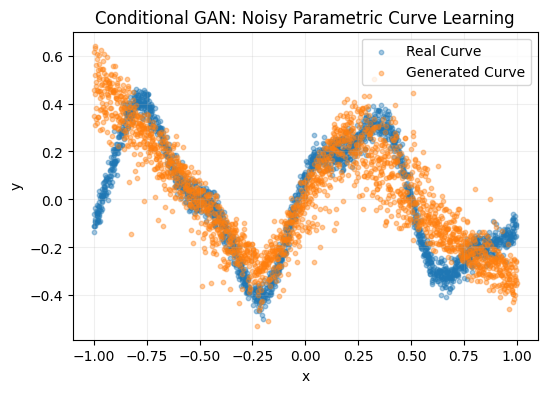

In [ ]:
G.eval()

with torch.no_grad():
    x_test = torch.linspace(-1, 1, 2000).unsqueeze(1).to(device)
    z = torch.randn(2000, noise_dim).to(device)

    y_gen = G(x_test, z).cpu().numpy()
    x_test = x_test.cpu().numpy()

real_np = real_data.cpu().numpy()

plt.figure(figsize=(6,4))

plt.scatter(real_np[:,0], real_np[:,1],
            s=10, alpha=0.4, label="Real Curve")

plt.scatter(x_test[:,0], y_gen[:,0],
            s=10, alpha=0.4, label="Generated Curve")

plt.title("Conditional GAN: Noisy Parametric Curve Learning")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(alpha=0.2)

plt.show()

## Task 3: Modify the GAN architecture

## Improved Generator

In [ ]:
class Generator(nn.Module):
    def __init__(self, noise_dim=8):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(noise_dim + 1, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.2),

            nn.Linear(128, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.2),

            nn.Linear(128, 64),
            nn.LeakyReLU(0.2),

            nn.Linear(64, 1),
            nn.Tanh()
        )

    def forward(self, x, z):
        inp = torch.cat([x, z], dim=1)
        return self.net(inp)

## Improved Discriminator

In [ ]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(2, 128),
            nn.LeakyReLU(0.2),

            nn.Linear(128, 128),
            nn.LeakyReLU(0.2),

            nn.Linear(128, 64),
            nn.LeakyReLU(0.2),

            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, xy):
        return self.net(xy)

## Initialize Model

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

noise_dim = 16

G = Generator(noise_dim).to(device)
D = Discriminator().to(device)

g_optimizer = torch.optim.Adam(G.parameters(), lr=0.0002, betas=(0.5, 0.999))
d_optimizer = torch.optim.Adam(D.parameters(), lr=0.0002, betas=(0.5, 0.999))

real_data = real_data / (torch.max(torch.abs(real_data)) + 1e-8)

## Training

In [ ]:
epochs = 3000
batch_size = 64

for epoch in range(epochs):

    idx = torch.randint(0, real_data.size(0), (batch_size,))
    real = real_data[idx]

    x_real = real[:, 0].unsqueeze(1)
    y_real = real[:, 1].unsqueeze(1)

    # Fake data generation

    z = torch.randn(batch_size, noise_dim).to(device)
    y_fake = G(x_real, z)

    fake = torch.cat([x_real, y_fake], dim=1)

    real_labels = torch.ones(batch_size, 1).to(device)
    fake_labels = torch.zeros(batch_size, 1).to(device)

    # Train Discriminator

    d_optimizer.zero_grad()

    d_real = D(torch.cat([x_real, y_real], dim=1))
    d_fake = D(fake.detach())

    d_loss = criterion(d_real, real_labels) + criterion(d_fake, fake_labels)

    d_loss.backward()
    d_optimizer.step()


    # Train Generator

    g_optimizer.zero_grad()

    z = torch.randn(batch_size, noise_dim).to(device)
    y_fake = G(x_real, z)
    fake = torch.cat([x_real, y_fake], dim=1)

    g_loss = criterion(D(fake), real_labels)

    g_loss.backward()
    g_optimizer.step()

    if epoch % 100 == 0:
        print(f"Epoch {epoch} | D Loss: {d_loss.item():.4f} | G Loss: {g_loss.item():.4f}")



Epoch 0 | D Loss: 1.3970 | G Loss: 0.7905
Epoch 100 | D Loss: 1.3813 | G Loss: 0.7026
Epoch 200 | D Loss: 1.3527 | G Loss: 0.7080
Epoch 300 | D Loss: 1.3693 | G Loss: 0.7028
Epoch 400 | D Loss: 1.2991 | G Loss: 0.7627
Epoch 500 | D Loss: 1.2348 | G Loss: 0.7880
Epoch 600 | D Loss: 1.1233 | G Loss: 0.9474
Epoch 700 | D Loss: 1.0206 | G Loss: 1.0174
Epoch 800 | D Loss: 0.9763 | G Loss: 1.1071
Epoch 900 | D Loss: 0.9551 | G Loss: 1.2086
Epoch 1000 | D Loss: 0.9627 | G Loss: 1.1763
Epoch 1100 | D Loss: 0.9998 | G Loss: 1.0738
Epoch 1200 | D Loss: 1.1192 | G Loss: 0.9297
Epoch 1300 | D Loss: 1.1532 | G Loss: 1.0023
Epoch 1400 | D Loss: 1.2255 | G Loss: 0.9329
Epoch 1500 | D Loss: 1.1381 | G Loss: 0.9758
Epoch 1600 | D Loss: 1.2543 | G Loss: 0.8809
Epoch 1700 | D Loss: 1.1311 | G Loss: 1.0473
Epoch 1800 | D Loss: 1.1309 | G Loss: 0.9665
Epoch 1900 | D Loss: 1.1635 | G Loss: 1.0157
Epoch 2000 | D Loss: 1.0019 | G Loss: 1.0102
Epoch 2100 | D Loss: 1.0783 | G Loss: 1.1651
Epoch 2200 | D Loss: 1

## Visual Comparison between original & generated sample

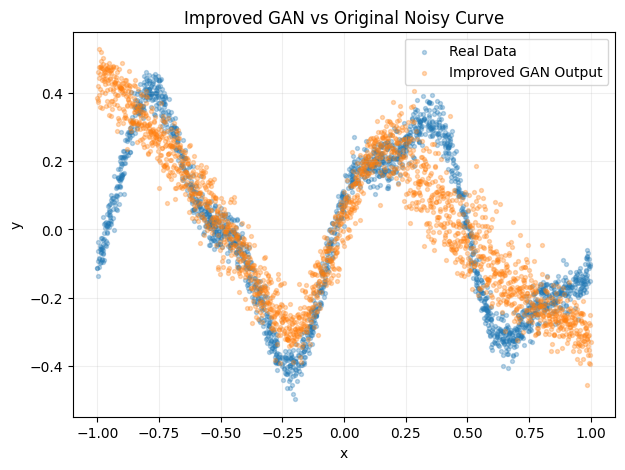

In [ ]:
G.eval()

with torch.no_grad():
    x_test = torch.linspace(-1, 1, 2000).unsqueeze(1).to(device)

    # multiple noise samples per x (smooth estimate)
    z = torch.randn(2000, noise_dim).to(device)
    y_gen = G(x_test, z).cpu().numpy()

    x_test_np = x_test.cpu().numpy()

real_np = real_data.cpu().numpy()

plt.figure(figsize=(7,5))

# real
plt.scatter(real_np[:,0], real_np[:,1],
            s=8, alpha=0.3, label="Real Data")

# generated
plt.scatter(x_test_np[:,0], y_gen[:,0],
            s=8, alpha=0.3, label="Improved GAN Output")

plt.title("Improved GAN vs Original Noisy Curve")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(alpha=0.2)

plt.show()

# Part 2: Real-World GAN Applications
## Part 2.1: Blood Cell Microscope Imaging with MedMNIST

In [ ]:
## Install & Imports
!pip install medmnist

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as T
from torch.utils.data import DataLoader

import medmnist
from medmnist import INFO

import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

## Device Setting

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Load BloodMNIST Dataset

In [ ]:
dataset_name = "bloodmnist"
dataset_info = INFO[dataset_name]
DataClass = getattr(medmnist, dataset_info["python_class"])

transform = T.Compose([
    T.Resize((32, 32)),
    T.ToTensor(),
    T.Normalize(mean=[0.5], std=[0.5])
])

train_data = DataClass(split="train", transform=transform, download=True)

train_loader = DataLoader(
    train_data,
    batch_size=128,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

## Visualise Sample Images

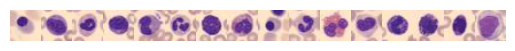

In [ ]:
def show_samples(loader):
    imgs, _ = next(iter(loader))
    imgs = imgs[:16]

    imgs = (imgs + 1) / 2  # denormalize

    grid = torch.cat([img for img in imgs], dim=2)
    plt.imshow(grid.permute(1,2,0))
    plt.axis('off')
    plt.show()

show_samples(train_loader)

## Define WGAN-GP Generator

In [ ]:
class Generator(nn.Module):
    def __init__(self, latent_dim=100):
        super().__init__()

        self.net = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, 256, 4, 1, 0),
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            nn.ConvTranspose2d(256, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64, 3, 4, 2, 1),
            nn.Tanh()
        )

    def forward(self, z):
        return self.net(z)

##  Define WGAN-GP Critic

In [ ]:
class Critic(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1),
            nn.LeakyReLU(0.2),

            nn.Conv2d(64, 128, 4, 2, 1),
            nn.InstanceNorm2d(128, affine=True),
            nn.LeakyReLU(0.2),

            nn.Conv2d(128, 256, 4, 2, 1),
            nn.InstanceNorm2d(256, affine=True),
            nn.LeakyReLU(0.2),

            nn.Conv2d(256, 1, 4, 1, 0)
        )

    def forward(self, x):
        return self.net(x).view(-1)

## Gradient Penalty (CORE of WGAN-GP)

In [ ]:
def gradient_penalty(critic, real, fake, device):
    batch_size = real.size(0)
    epsilon = torch.rand(batch_size, 1, 1, 1).to(device)

    interpolated = epsilon * real + (1 - epsilon) * fake
    interpolated.requires_grad_(True)

    scores = critic(interpolated)

    gradients = torch.autograd.grad(
        outputs=scores,
        inputs=interpolated,
        grad_outputs=torch.ones_like(scores),
        create_graph=True,
        retain_graph=True
    )[0]

    gradients = gradients.view(batch_size, -1)
    gp = ((gradients.norm(2, dim=1) - 1) ** 2).mean()

    return gp

## Initialize Models

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

latent_dim = 100

G = Generator(latent_dim).to(device)
C = Critic().to(device)

opt_G = optim.Adam(G.parameters(), lr=1e-4, betas=(0.0, 0.9))
opt_C = optim.Adam(C.parameters(), lr=1e-4, betas=(0.0, 0.9))

## Training Loop (WGAN-GP)

In [ ]:
epochs = 10
lambda_gp = 10
critic_steps = 2

g_losses = []
c_losses = []

for epoch in range(epochs):
    loop = tqdm(train_loader)

    for real_imgs, _ in loop:
        real_imgs = real_imgs.to(device)
        batch_size = real_imgs.size(0)


        # Train Critic

        for _ in range(critic_steps):
            z = torch.randn(batch_size, latent_dim, 1, 1).to(device)
            fake_imgs = G(z)

            critic_real = C(real_imgs)
            critic_fake = C(fake_imgs.detach())

            gp = gradient_penalty(C, real_imgs, fake_imgs, device)

            loss_C = -(torch.mean(critic_real) - torch.mean(critic_fake)) + lambda_gp * gp

            opt_C.zero_grad()
            loss_C.backward()
            opt_C.step()

        # Train Generator

        z = torch.randn(batch_size, latent_dim, 1, 1).to(device)
        fake_imgs = G(z)
        loss_G = -torch.mean(C(fake_imgs))

        opt_G.zero_grad()
        loss_G.backward()
        opt_G.step()

        g_losses.append(loss_G.item())
        c_losses.append(loss_C.item())

        loop.set_description(f"Epoch [{epoch+1}/{epochs}]")
        loop.set_postfix(g_loss=loss_G.item(), c_loss=loss_C.item())

Epoch [10/10]: 100%|██████████| 94/94 [06:57<00:00,  4.44s/it, c_loss=-3.13, g_loss=6.05]


## Generate Fake Blood Images

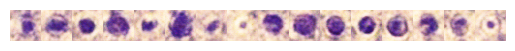

In [ ]:
def generate_images(model, n=16):
    z = torch.randn(n, latent_dim, 1, 1).to(device)
    imgs = model(z).detach().cpu()
    imgs = (imgs + 1) / 2

    grid = torch.cat([img for img in imgs], dim=2)
    plt.imshow(grid.permute(1,2,0))
    plt.axis('off')
    plt.show()

generate_images(G)

## Plot Loss Curves

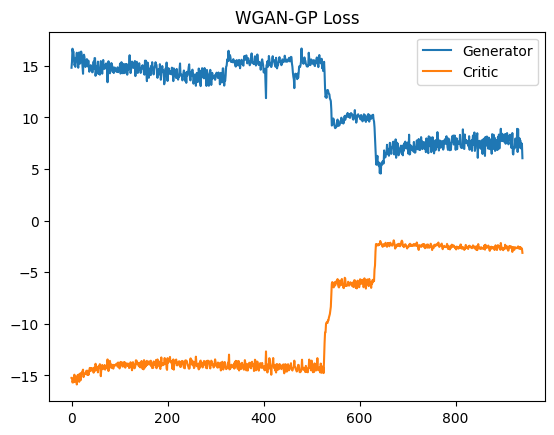

In [ ]:
plt.plot(g_losses, label="Generator")
plt.plot(c_losses, label="Critic")
plt.legend()
plt.title("WGAN-GP Loss")
plt.show()

## FID Score

In [ ]:
!pip install pytorch-fid

In [ ]:
import os

os.makedirs("real_images", exist_ok=True)
os.makedirs("fake_images", exist_ok=True)

In [ ]:
import torchvision.utils as vutils

def save_real_images(loader, num_images=500):
    count = 0
    for imgs, _ in loader:
        imgs = (imgs + 1) / 2  # denormalize

        for img in imgs:
            vutils.save_image(img, f"real_images/{count}.png")
            count += 1
            if count >= num_images:
                return

save_real_images(train_loader)

In [ ]:
def save_fake_images(model, num_images=500):
    model.eval()
    count = 0

    with torch.no_grad():
        while count < num_images:
            z = torch.randn(32, latent_dim, 1, 1).to(device)
            fake_imgs = model(z)
            fake_imgs = (fake_imgs + 1) / 2

            for img in fake_imgs:
                vutils.save_image(img, f"fake_images/{count}.png")
                count += 1
                if count >= num_images:
                    break

    model.train()

save_fake_images(G)

In [ ]:
from pytorch_fid import fid_score

fid = fid_score.calculate_fid_given_paths(
    ["real_images", "fake_images"],
    batch_size=32,
    device=device,
    dims=2048
)

print("FID Score:", fid)

Downloading: "https://github.com/mseitzer/pytorch-fid/releases/download/fid_weights/pt_inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/pt_inception-2015-12-05-6726825d.pth


100%|██████████| 91.2M/91.2M [00:00<00:00, 139MB/s]
100%|██████████| 16/16 [02:59<00:00, 11.23s/it]


FID Score: 419.02444353560406


## Part 2.2: Cybersecurity – Synthetic Traffic with CICIDS 2017

##  Load & Combine CSVs from ZIP

In [ ]:
import zipfile
import pandas as pd

zip_path = "/content/drive/MyDrive/2nd Year/Semester B/Assignment/Generative modelling case study (40%)/CICIDS 2017 (DDoS and BENIGN labels) .zip"

def load_all_csvs(zip_path):
    frames = []

    with zipfile.ZipFile(zip_path, 'r') as archive:
        csv_files = [f for f in archive.namelist() if f.endswith(".csv")]
        print("Found files:", len(csv_files))

        for file in csv_files:
            with archive.open(file) as f:
                df = pd.read_csv(f)
                frames.append(df)

    return pd.concat(frames, ignore_index=True)

dataset_all = load_all_csvs(zip_path)
print("Dataset shape:", dataset_all.shape)

Found files: 8
Dataset shape: (2830743, 79)


In [ ]:
data = dataset_all.copy()

data.columns = data.columns.str.strip()
data['Label'] = data[' Label'] if ' Label' in data.columns else data['Label']

print(data['Label'].value_counts())
print(data.isna().sum().sort_values(ascending=False).head(10))

Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64
Flow Bytes/s                   1358
Flow Duration                     0
Destination Port                  0
Total Backward Packets            0
Total Length of Fwd Packets       0
Total Length of Bwd Packets       0
Total Fwd Packets                 0
Fwd Packet Length Max             0
Fwd Packet Length Min             0
Fwd Packet Length Std             0
dtype: int64


## Load Wednesday dataset ONLY

In [ ]:
target_day = "Wednesday-workingHours.pcap_ISCX.csv"

with zipfile.ZipFile(zip_path, 'r') as archive:
    file_name = [f for f in archive.namelist() if target_day in f][0]
    with archive.open(file_name) as f:
        data = pd.read_csv(f)

data.columns = data.columns.str.strip()
print("Shape:", data.shape)
print(data['Label'].value_counts())

Shape: (692703, 79)
Label
BENIGN              440031
DoS Hulk            231073
DoS GoldenEye        10293
DoS slowloris         5796
DoS Slowhttptest      5499
Heartbleed              11
Name: count, dtype: int64


In [ ]:
# Clean column names
data.columns = data.columns.str.strip()

print(data.shape)
print(data['Label'].value_counts())

(692703, 79)
Label
BENIGN              440031
DoS Hulk            231073
DoS GoldenEye        10293
DoS slowloris         5796
DoS Slowhttptest      5499
Heartbleed              11
Name: count, dtype: int64


## Filter BENIGN + DoS only

In [ ]:
filtered = data[
    data['Label'].str.contains("BENIGN|DoS", case=False, na=False)
].copy()

filtered['target'] = filtered['Label'].apply(lambda x: 0 if "BENIGN" in x else 1)

print(filtered['target'].value_counts())

target
0    440031
1    252661
Name: count, dtype: int64


## Clean + prepare features

In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

filtered = filtered.replace([np.inf, -np.inf], np.nan).dropna()

X = filtered.drop(columns=['Label', 'target'])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X).astype(np.float32)

X_train, X_test = train_test_split(X_scaled, test_size=0.2, random_state=42)

feature_dim = X_train.shape[1]

## Convert to PyTorch DataLoader

In [ ]:
import torch
from torch.utils.data import DataLoader, TensorDataset

train_tensor = torch.tensor(X_train, dtype=torch.float32)

loader = DataLoader(
    TensorDataset(train_tensor),
    batch_size=256,
    shuffle=True
)

## Build GAN (MLP for tabular data)

In [ ]:
import torch.nn as nn

latent_dim = 32

class Generator(nn.Module):
    def __init__(self, z_dim, out_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(z_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, out_dim)
        )

    def forward(self, z):
        return self.model(z)


class Discriminator(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(in_dim, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

##  Initialize model + optimizer

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

G = Generator(latent_dim, feature_dim).to(device)
D = Discriminator(feature_dim).to(device)

loss_fn = nn.BCELoss()

opt_g = torch.optim.Adam(G.parameters(), lr=2e-4)
opt_d = torch.optim.Adam(D.parameters(), lr=2e-4)

##  Train GAN (with loss tracking)

In [ ]:
epochs = 50

g_history, d_history = [], []

for epoch in range(epochs):

    for (real_batch,) in loader:
        real_batch = real_batch.to(device)
        batch_size = real_batch.size(0)

        valid = torch.ones(batch_size, 1, device=device)
        fake = torch.zeros(batch_size, 1, device=device)

        # ---- Train Discriminator ----
        z = torch.randn(batch_size, latent_dim, device=device)
        generated = G(z)

        d_real = D(real_batch)
        d_fake = D(generated.detach())

        d_loss = loss_fn(d_real, valid) + loss_fn(d_fake, fake)

        opt_d.zero_grad()
        d_loss.backward()
        opt_d.step()

        # ---- Train Generator ----
        z = torch.randn(batch_size, latent_dim, device=device)
        generated = G(z)

        g_loss = loss_fn(D(generated), valid)

        opt_g.zero_grad()
        g_loss.backward()
        opt_g.step()

    g_history.append(g_loss.item())
    d_history.append(d_loss.item())

    print(f"Epoch {epoch+1}/{epochs} | D: {d_loss.item():.4f} | G: {g_loss.item():.4f}")

Epoch 1/50 | D Loss: 0.1167 | G Loss: 3.0683
Epoch 2/50 | D Loss: 0.1563 | G Loss: 4.4991
Epoch 3/50 | D Loss: 0.1153 | G Loss: 5.6933
Epoch 4/50 | D Loss: 0.3279 | G Loss: 3.6781
Epoch 5/50 | D Loss: 0.3516 | G Loss: 3.2591
Epoch 6/50 | D Loss: 0.4079 | G Loss: 2.9870
Epoch 7/50 | D Loss: 0.5074 | G Loss: 2.9521
Epoch 8/50 | D Loss: 0.5600 | G Loss: 3.1317
Epoch 9/50 | D Loss: 0.8227 | G Loss: 2.3607
Epoch 10/50 | D Loss: 0.6706 | G Loss: 2.2005
Epoch 11/50 | D Loss: 0.8199 | G Loss: 1.7889
Epoch 12/50 | D Loss: 0.4623 | G Loss: 2.3768
Epoch 13/50 | D Loss: 0.7240 | G Loss: 2.1102
Epoch 14/50 | D Loss: 0.9727 | G Loss: 1.8117
Epoch 15/50 | D Loss: 0.5471 | G Loss: 1.8533
Epoch 16/50 | D Loss: 0.5477 | G Loss: 2.1063
Epoch 17/50 | D Loss: 0.6943 | G Loss: 2.1651
Epoch 18/50 | D Loss: 0.6346 | G Loss: 1.8215
Epoch 19/50 | D Loss: 0.7691 | G Loss: 1.9324
Epoch 20/50 | D Loss: 0.7390 | G Loss: 2.1613
Epoch 21/50 | D Loss: 0.6855 | G Loss: 2.2187
Epoch 22/50 | D Loss: 0.5106 | G Loss: 2.30

## Plot training losses

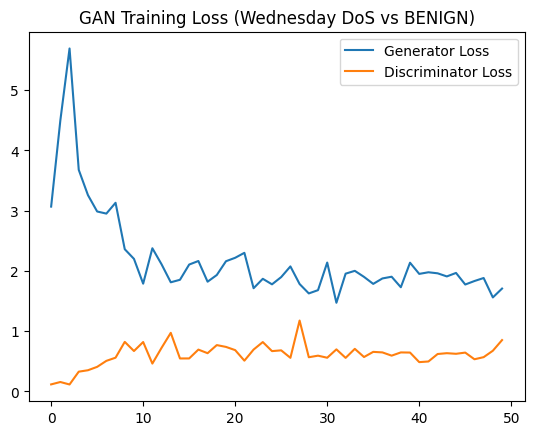

In [ ]:
import matplotlib.pyplot as plt

plt.plot(g_history, label="Generator")
plt.plot(d_history, label="Discriminator")
plt.title("GAN Training Dynamics")
plt.legend()
plt.show()

## Generate synthetic feature vectors

In [ ]:
G.eval()

with torch.no_grad():
    z = torch.randn(len(X_train), latent_dim, device=device)
    synthetic_data = G(z).cpu().numpy()

## Correct Real vs Fake Comparison

In [ ]:
real_data = X_test
fake_data = synthetic_data[:len(X_test)]

## t-SNE visualization

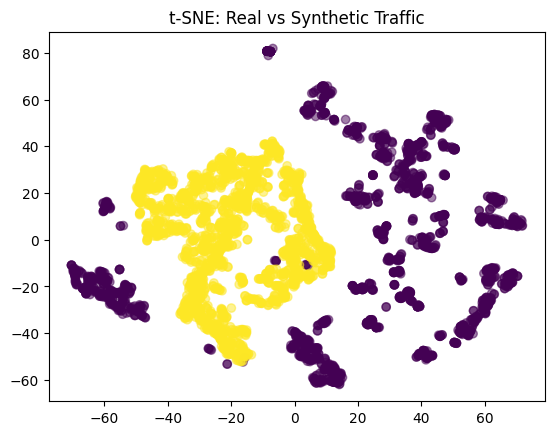

In [ ]:
from sklearn.manifold import TSNE
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

sample_size = 2000

real_sample = real_data[np.random.choice(len(real_data), sample_size, replace=False)]
fake_sample = fake_data[np.random.choice(len(fake_data), sample_size, replace=False)]

combined = np.vstack([real_sample, fake_sample])
labels = np.array([0]*sample_size + [1]*sample_size)

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
embeddings = tsne.fit_transform(combined)

plt.scatter(embeddings[:,0], embeddings[:,1], c=labels, alpha=0.5)
plt.title("t-SNE: Real vs Synthetic Traffic")
plt.show()

## Evaluation (distribution similarity)

In [ ]:
from scipy.stats import ks_2samp

mean_gap = np.mean(np.abs(real_data.mean(axis=0) - fake_data.mean(axis=0)))
std_gap = np.mean(np.abs(real_data.std(axis=0) - fake_data.std(axis=0)))

ks_vals = [
    ks_2samp(real_data[:, i], fake_data[:, i]).statistic
    for i in range(real_data.shape[1])
]

print("Mean difference:", mean_gap)
print("Std difference:", std_gap)
print("Avg KS statistic:", np.mean(ks_vals))

Mean difference: 0.31246924
Std difference: 0.8375325
Avg KS statistic: 0.7431423018605454


## Part 2.3: Creative AI – QuickDraw 'Pizza' Subset

In [ ]:
# Imports

import os
import json
import numpy as np
import matplotlib.pyplot as plt
import cv2

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
from scipy.linalg import sqrtm

In [ ]:
import requests

url = "https://storage.googleapis.com/quickdraw_dataset/full/simplified/pizza.ndjson"
r = requests.get(url)

with open("pizza.ndjson", "wb") as f:
    f.write(r.content)

## Load & Filter Samples

In [ ]:
def load_recognized_drawings(path, max_items=10000):
    collected = []

    with open(path, "r") as f:
        for line in f:
            record = json.loads(line)

            if record.get("recognized", False):
                collected.append(record["drawing"])

            if len(collected) >= max_items:
                break

    return collected


drawings = load_recognized_drawings("pizza.ndjson", max_items=10000)
print("Samples loaded:", len(drawings))


Samples loaded: 10000


## Visualize Stroke Data

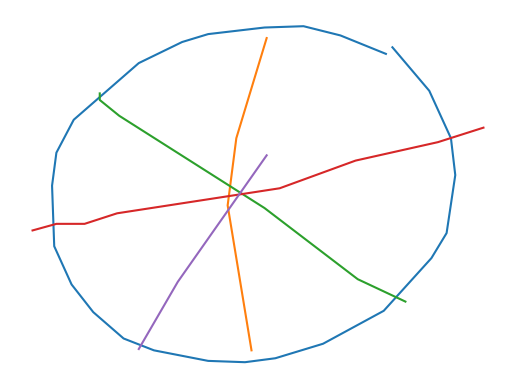

In [ ]:
def plot_strokes(sample):
    for stroke in sample:
        x, y = stroke
        plt.plot(x, y)

    plt.gca().invert_yaxis()
    plt.axis("off")
    plt.show()

plot_strokes(drawings[5])

## Convert Strokes → Image

In [ ]:
def strokes_to_image(strokes, output_size=28):
    canvas = np.zeros((256, 256), dtype=np.uint8)

    for stroke in strokes:
        xs, ys = stroke

        for i in range(len(xs) - 1):
            pt1 = (xs[i], ys[i])
            pt2 = (xs[i + 1], ys[i + 1])
            cv2.line(canvas, pt1, pt2, 255, 2)

    resized = cv2.resize(canvas, (output_size, output_size))
    return resized

## Convert dataset

In [ ]:
image_data = np.array([strokes_to_image(d) for d in drawings])

# Normalize to [-1, 1]
image_data = (image_data / 127.5) - 1.0

# reshape for CNN (N, C, H, W)
image_data = image_data.reshape(-1, 1, 28, 28)

print("Image tensor shape:", image_data.shape)

Image tensor shape: (10000, 1, 28, 28)


## Show Samples

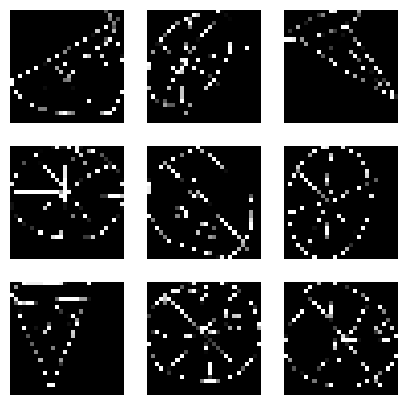

In [ ]:
def show_grid(images, count=9):
    plt.figure(figsize=(5, 5))

    for i in range(count):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i][0], cmap="gray")
        plt.axis("off")

    plt.show()

show_grid(image_data)

## Dataset Wrapper

In [ ]:
class PizzaSketchDataset(Dataset):
    def __init__(self, array):
        self.data = torch.tensor(array, dtype=torch.float32)

    def __len__(self):
        return self.data.shape[0]

    def __getitem__(self, idx):
        return self.data[idx]


dataset = PizzaSketchDataset(image_data)
loader = DataLoader(dataset, batch_size=128, shuffle=True)

## DCGAN Architecture

In [ ]:
class GenNet(nn.Module):
    def __init__(self, latent_dim=100):
        super().__init__()

        self.model = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, 128, 7, 1, 0),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64, 1, 4, 2, 1),
            nn.Tanh()
        )

    def forward(self, z):
        return self.model(z)


class DiscNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Conv2d(1, 64, 4, 2, 1),
            nn.LeakyReLU(0.2),

            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),

            nn.Flatten(),
            nn.Linear(128 * 7 * 7, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

## Training Setup

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

G = GenNet().to(device)
D = DiscNet().to(device)

loss_fn = nn.BCELoss()

opt_g = torch.optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
opt_d = torch.optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))

latent_dim = 100

## Training Loop

In [ ]:
epochs = 10
g_history, d_history = [], []

for ep in range(epochs):
    for batch in loader:

        real_imgs = batch.to(device)
        bs = real_imgs.size(0)

        real_lbl = torch.ones(bs, 1).to(device)
        fake_lbl = torch.zeros(bs, 1).to(device)

        # ---- Train Discriminator ----
        noise = torch.randn(bs, latent_dim, 1, 1).to(device)
        fake_imgs = G(noise)

        d_real = loss_fn(D(real_imgs), real_lbl)
        d_fake = loss_fn(D(fake_imgs.detach()), fake_lbl)

        d_loss = d_real + d_fake

        opt_d.zero_grad()
        d_loss.backward()
        opt_d.step()

        # ---- Train Generator ----
        noise = torch.randn(bs, latent_dim, 1, 1).to(device)
        gen_imgs = G(noise)

        g_loss = loss_fn(D(gen_imgs), real_lbl)

        opt_g.zero_grad()
        g_loss.backward()
        opt_g.step()

    g_history.append(g_loss.item())
    d_history.append(d_loss.item())

    print(f"Epoch {ep+1}/{epochs} | D: {d_loss.item():.4f} | G: {g_loss.item():.4f}")


Epoch 1/10 | D: 0.0306 | G: 4.6826
Epoch 2/10 | D: 0.0051 | G: 6.0477
Epoch 3/10 | D: 0.8615 | G: 3.4143
Epoch 4/10 | D: 0.8946 | G: 1.5314
Epoch 5/10 | D: 0.8441 | G: 1.8343
Epoch 6/10 | D: 0.9970 | G: 1.7847
Epoch 7/10 | D: 0.8048 | G: 1.2468
Epoch 8/10 | D: 0.8877 | G: 1.3419
Epoch 9/10 | D: 0.9334 | G: 2.4338
Epoch 10/10 | D: 1.1799 | G: 2.2839


## Loss Plot


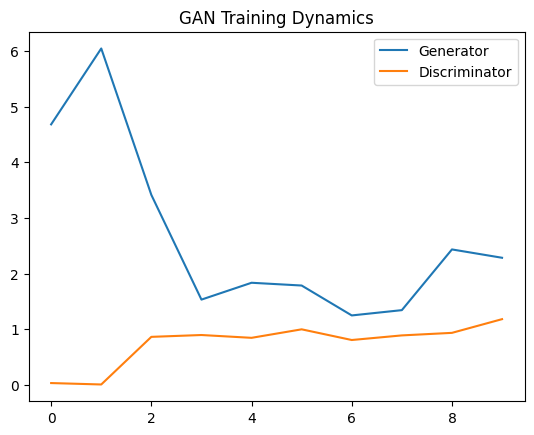

In [ ]:
plt.plot(g_history, label="Generator")
plt.plot(d_history, label="Discriminator")
plt.legend()
plt.title("GAN Training Dynamics")
plt.show()

## Generate Samples

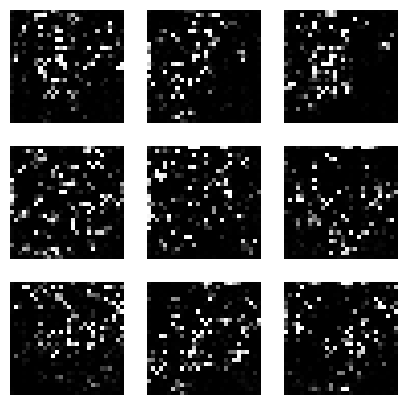

In [ ]:
def sample_generator(model, n=9):
    model.eval()
    z = torch.randn(n, latent_dim, 1, 1).to(device)

    with torch.no_grad():
        outputs = model(z).cpu()

    plt.figure(figsize=(5, 5))

    for i in range(n):
        plt.subplot(3, 3, i + 1)
        plt.imshow(outputs[i][0], cmap="gray")
        plt.axis("off")

    plt.show()

sample_generator(G)

## Real vs Fake Comparison

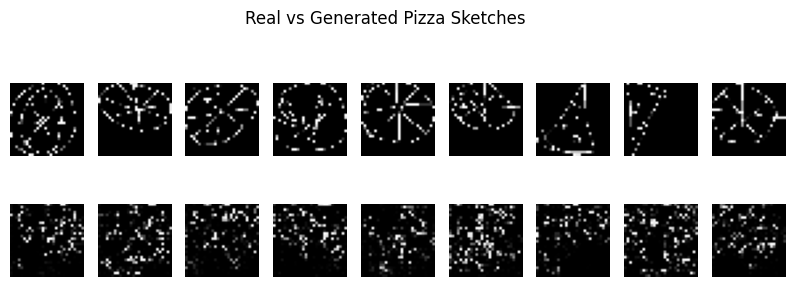

In [ ]:
def compare_outputs(model, data_loader, n=9):

    real_batch = next(iter(data_loader))
    real_batch = real_batch.to(device)

    z = torch.randn(n, latent_dim, 1, 1).to(device)

    with torch.no_grad():
        fake_batch = model(z).cpu()

    real_batch = real_batch.cpu()

    plt.figure(figsize=(10, 6))

    for i in range(n):

        plt.subplot(4, n, i + 1)
        plt.imshow(real_batch[i][0], cmap="gray")
        plt.axis("off")

        plt.subplot(4, n, i + 1 + n)
        plt.imshow(fake_batch[i][0], cmap="gray")
        plt.axis("off")

    plt.suptitle("Real vs Generated Pizza Sketches")
    plt.show()


compare_outputs(G, loader)